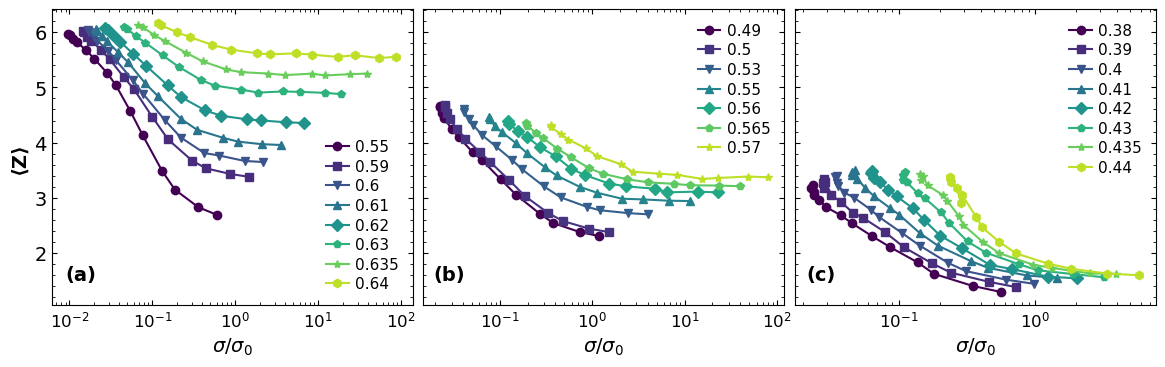

In [2]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

fig_names = ['fig1.pkl', 'fig2.pkl', 'fig3.pkl']
titles = ['Title 1', 'Title 2', 'Title 3']

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True, 
                         constrained_layout=False)

for ax_new, fname, title in zip(axes, fig_names, titles):
    with open(fname, 'rb') as f:
        fig_old = pickle.load(f)
    plt.close(fig_old)
    
    ax_old = fig_old.axes[0]
    lines = ax_old.get_lines()
    colours = plt.cm.viridis(np.linspace(0, 0.9, len(lines)))
    
    for line, colour in zip(lines, colours):
        label = line.get_label().split('=')[-1]  # 'φ=0.55' -> '0.55'
        ax_new.plot(line.get_xdata(), line.get_ydata(),
                    marker=line.get_marker(),
                    color=colour,
                    linestyle=line.get_linestyle(),
                    label=label)
    
    ax_new.set_xscale('log')
    ax_new.set_xlabel('$\\sigma / \\sigma_0$', fontsize=14, fontweight='bold')
    ax_new.minorticks_on()
    ax_new.tick_params(axis='both', which='both', direction='in',
                   top=True, right=True, labelsize=12)
    ax_new.legend(fontsize=11, handlelength=1.5, borderpad=0.4, 
                  labelspacing=0.3, handletextpad=0.4, frameon=False)

axes[0].set_ylabel('⟨Z⟩', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='y', labelleft=True, labelsize=14)
axes[0].text(0.009, 1.5, '(a)', fontsize=14, fontweight='bold')
axes[1].text(0.019, 1.5,  '(b)', fontsize=14, fontweight='bold')
axes[2].text(0.021, 1.5, '(c)', fontsize=14, fontweight='bold')

for ax in axes[1:]:
    ax.tick_params(axis='y', labelleft=False)

# This controls the spacing - adjust top/bottom to taste
fig.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.18, wspace=0.03)
plt.savefig('z_joint_flow', dpi=1200)
plt.show()